# Feedforward Pointcloud Reconstruction

This tutorial runs **VGGT-Omega** feedforward reconstruction (no optimisation loop) on the pipeline keyframes and writes the zarr cache that downstream notebooks — `semantic_lifting`, `localization`, and `bundle_adjustment` — read. **Run this notebook before any of those.**

**Prerequisite:** keyframes in `FRAMES` — run the dashboard pipeline or [tutorial 01](../01_preprocessing/keyframe_extraction.ipynb) first.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import numpy as np
import open3d as o3d
import pyvista as pv
import torch

# Static backend for headless (nbconvert) execution; interactive trame otherwise
pv.set_jupyter_backend("static" if os.environ.get("PYVISTA_OFF_SCREEN") else "trame")

from collab_splats.pointcloud import make_creator
from collab_splats.pointcloud.feedforward import FeedforwardResult
from collab_splats.pointcloud.utils import clean_pointcloud
from collab_splats.utils.visualization import (
    CAMERA_KWARGS,
    PCD_KWARGS,
    VIZ_KWARGS,
    pointcloud_to_polydata,
    visualize_splat,
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 12.8
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX A5000" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.14.0


/opt/venv/reconstruction/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/opt/venv/reconstruction/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/opt/venv/reconstruction/lib/python3.11/site-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/opt/venv/reconstruction/lib/python3.11/site-packages/mobile_sam/modeling/ti

In [3]:
%run ../tutorial_config.py

# ── Configuration ─────────────────────────────────────────────────────────────

# Pipeline keyframes: read-only input from the canonical scene dir
image_paths = sorted(FRAMES.glob("*.jpg")) + sorted(FRAMES.glob("*.png"))
assert image_paths, f"no keyframes in {FRAMES} — run the dashboard pipeline or tutorial 01"
image_paths = image_paths[:MAX_FRAMES]
print(f"{len(image_paths)} keyframes from {FRAMES}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")


def _clean(result):
    """Filter outliers, downsample; return (pts3d, colors, conf_mean, conf_std).

    Note: conf_mean/conf_std are computed on the raw (pre-filter) confidence tensor.
    """
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(result.points)
    pcd.colors = o3d.utility.Vector3dVector(result.colors.astype(np.float64) / 255.0)
    cleaned, _ = clean_pointcloud(pcd)
    pts3d = np.asarray(cleaned.points, dtype=np.float32)
    colors = (np.asarray(cleaned.colors) * 255).astype(np.uint8)
    conf = result.confidence
    conf_mean = conf.cpu().float().mean().item() if conf is not None else float("nan")
    conf_std  = conf.cpu().float().std().item()  if conf is not None else float("nan")
    print(f"Points: {len(result.points):,} raw → {len(pts3d):,} filtered")
    print(f"Conf:   mean={conf_mean:.3f}  std={conf_std:.3f}")
    return pts3d, colors, conf_mean, conf_std

30 keyframes from /workspace/outputs/2024_02_06/C0043/frames
device: cuda


## VGGT-Omega Reconstruction

Loads a cached reconstruction from `TUTORIAL_CACHE / "vggt_omega.zarr"` if available, skipping GPU inference. Otherwise runs VGGT-Omega — a unified vision transformer predicting camera poses and dense depth in one forward pass — on the keyframe subset and saves the zarr cache that downstream notebooks read.

In [4]:
# Run VGGT-Omega once; later executions reload the zarr cache
_omega_cache = TUTORIAL_CACHE / "vggt_omega.zarr"
_omega_cache.parent.mkdir(parents=True, exist_ok=True)

if _omega_cache.exists():
    result = FeedforwardResult.load_zarr(_omega_cache)
    print(f"loaded cached reconstruction ({result.points.shape[0]:,} pts)")
else:
    # The creator API consumes a directory — stage the MAX_FRAMES subset as symlinks
    _subset_dir = TUTORIAL_CACHE / "omega_frames"
    _subset_dir.mkdir(parents=True, exist_ok=True)
    for p in image_paths:
        link = _subset_dir / p.name
        if not link.exists():
            link.symlink_to(p)
    result = make_creator("vggt_omega").run(_subset_dir, device)
    result.save_zarr(_omega_cache)
    print(f"reconstructed {result.points.shape[0]:,} pts → {_omega_cache}")

[23:00:55] Loading model (cuda)...                                                                      ]8;id=10733443;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=10733444;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#800\800]8;;\

/workspace/collab-splats/collab_splats/pointcloud/feedforward/vggt_omega.py:181: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(str(ckpt_path

[23:01:31]   done in 35.5s                                                                              ]8;id=10733450;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=10733451;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#802\802]8;;\

           Preprocessing images...                                                                      ]8;id=10733457;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=10733458;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#806\806]8;;\

[23:01:34]   → 30 images  done in 3.2s                                                                  ]8;id=10733464;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=10733465;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#808\808]8;;\

           Running inference...                                                                         ]8;id=10733471;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=10733472;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#812\812]8;;\

[23:01:37]   done in 3.5s                                                                               ]8;id=10733478;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=10733479;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#817\817]8;;\

           Postprocessing...                                                                            ]8;id=10733485;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=10733486;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#821\821]8;;\

[23:01:39]   → 500,000 pts  done in 1.7s                                                                ]8;id=10733492;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=10733493;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#824\824]8;;\

reconstructed 500,000 pts → /workspace/outputs/tutorial_cache/2024_02_06/C0043/vggt_omega.zarr


## Post-processing

Removes statistical outliers and voxel-downsamples the raw pointcloud. Confidence statistics on the raw prediction help diagnose depth quality.

In [5]:
pts3d, colors, conf_mean, conf_std = _clean(result)

Points: 500,000 raw → 39,157 filtered
Conf:   mean=12.825  std=11.922


## Pointcloud Viewer

Renders the filtered pointcloud with camera frustums showing the predicted camera poses.

2026-07-18 23:01:43.125 (  60.597s) [    796020FCC740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


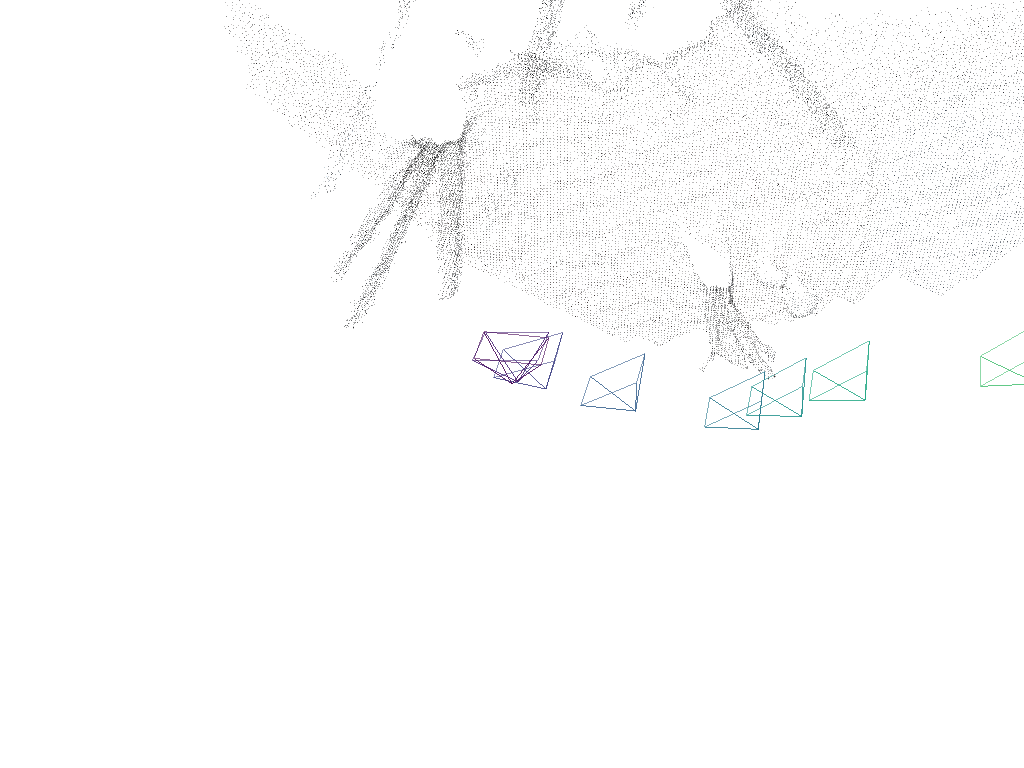

In [6]:
cloud = pointcloud_to_polydata(pts3d, RGB=colors)
visualize_splat(
    cloud,
    aligned_cameras=list(result.extrinsics),
    mesh_kwargs={**PCD_KWARGS, "rgb": True},
    camera_kwargs={k: v for k, v in CAMERA_KWARGS.items() if k != "color"},
    viz_kwargs=VIZ_KWARGS,
).show()

## Other backends

`make_creator(<name>)` swaps the reconstruction backend with no other code changes:

| name | model | notes |
|------|-------|-------|
| `"vggtx"` | VGGT-X | fastest baseline |
| `"mapanything"` | MapAnything | metric-scale output |
| `"vggt_spark"` | VGGT-SPARK | optional install |
| `"colmap"` / `"hloc"` | classical SfM | no GPU model, slower |

Optional backends only appear in the registry when their package is installed (`bash setup.sh` installs everything).